# Final Assignment

### Dataset
A Kaggle fictional dataset of transactions, normal and fraudulent.

### Objectives

1. The use of 4 different classification models to predict fraud.
2. Compare their performance based on fraud precision, recall, and f1 score, finding the best model.
3. Provide future directions.

### Library Imports

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import classification_report, confusion_matrix

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score

from sklearn.ensemble import HistGradientBoostingClassifier


### Data Import and Pre-processing

The data comes in 3 different CSV files and json files. In this step, they are compiled into 1 master dataframe.

In [3]:
cards=pd.read_csv('cards_data.csv')
usersData=pd.read_csv('users_data.csv')
transactions=pd.read_csv('transactions_data.csv')

In [4]:
import json
with open('mcc_codes.json') as f:
    mcc = json.load(f)
mcc_df=pd.DataFrame([
    {"mcc_code":int(k),"mcc_desc":v}
    for k,v in mcc.items()
])
mcc_df.head()

,mcc_code,mcc_desc
0,5812,Eating Places and Restaurants
1,5541,Service Stations
2,7996,"Amusement Parks, Carnivals, Circuses"
3,5411,"Grocery Stores, Supermarkets"
4,4784,Tolls and Bridge Fees


In [5]:
with open('train_fraud_labels.json') as fl:
    fraud_labels = json.load(fl)
    fraud_dict = fraud_labels["target"]
fraud_df=pd.DataFrame(list(fraud_dict.items()),columns=['transaction_id','is_fraud'])
fraud_df.head()

,transaction_id,is_fraud
0,10649266,No
1,23410063,No
2,9316588,No
3,12478022,No
4,9558530,No


In [6]:
tables = {
    "transactions": transactions,
    "usersData": usersData,
    "cards": cards
}

# Loop through them and print columns
for name, df in tables.items():
    print(f"{name}:")
    print(df.columns)

transactions:
Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors'],
      dtype='object')
usersData:
Index(['id', 'current_age', 'retirement_age', 'birth_year', 'birth_month',
       'gender', 'address', 'latitude', 'longitude', 'per_capita_income',
       'yearly_income', 'total_debt', 'credit_score', 'num_credit_cards'],
      dtype='object')
cards:
Index(['id', 'client_id', 'card_brand', 'card_type', 'card_number', 'expires',
       'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date',
       'year_pin_last_changed', 'card_on_dark_web'],
      dtype='object')


The full final dataframe

In [7]:
# Join transactions with usersData
df = transactions.merge(usersData, left_on='client_id', right_on='id', how='left', suffixes=('', '_user'))

# Join with cards
df = df.merge(cards, left_on='card_id', right_on='id', how='left', suffixes=('', '_card'))

# Join with MCC description
df = df.merge(mcc_df, left_on='mcc', right_on='mcc_code', how='left')

# Join with fraud labels
df['id'] = df['id'].astype(str)
fraud_df['transaction_id'] = fraud_df['transaction_id'].astype(str)
df = df.merge(fraud_df, left_on='id', right_on='transaction_id', how='left')
df.head()

,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,...,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,mcc_code,mcc_desc,transaction_id,is_fraud
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,...,YES,2,$55,05/2008,2008,No,5499,Miscellaneous Food Stores,7475327,No
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,...,YES,1,$9100,09/2005,2015,No,5311,Department Stores,7475328,No
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,...,YES,1,$14802,01/2006,2008,No,4829,Money Transfer,7475329,No
3,7475331,2010-01-01 00:05:00,430,2860,$200.00,Swipe Transaction,27092,Crown Point,IN,46307.0,...,NO,2,$37634,05/2004,2006,No,4829,Money Transfer,NaN,NaN
4,7475332,2010-01-01 00:06:00,848,3915,$46.41,Swipe Transaction,13051,Harwood,MD,20776.0,...,YES,1,$19113,07/2009,2014,No,5813,Drinking Places (Alcoholic Beverages),7475332,No


In [8]:
df.columns


Index(['id', 'date', 'client_id', 'card_id', 'amount', 'use_chip',
       'merchant_id', 'merchant_city', 'merchant_state', 'zip', 'mcc',
       'errors', 'id_user', 'current_age', 'retirement_age', 'birth_year',
       'birth_month', 'gender', 'address', 'latitude', 'longitude',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'id_card', 'client_id_card', 'card_brand',
       'card_type', 'card_number', 'expires', 'cvv', 'has_chip',
       'num_cards_issued', 'credit_limit', 'acct_open_date',
       'year_pin_last_changed', 'card_on_dark_web', 'mcc_code', 'mcc_desc',
       'transaction_id', 'is_fraud'],
      dtype='object')

There are objects, integers, and floats. We will have to encode the object features so that our models can handle them better. However, we should also consider how many dimensions they add to the analysis, as higher dimension features can heavily slow down models.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 43 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     object 
 1   date                   object 
 2   client_id              int64  
 3   card_id                int64  
 4   amount                 object 
 5   use_chip               object 
 6   merchant_id            int64  
 7   merchant_city          object 
 8   merchant_state         object 
 9   zip                    float64
 10  mcc                    int64  
 11  errors                 object 
 12  id_user                int64  
 13  current_age            int64  
 14  retirement_age         int64  
 15  birth_year             int64  
 16  birth_month            int64  
 17  gender                 object 
 18  address                object 
 19  latitude               float64
 20  longitude              float64
 21  per_capita_income      object 
 22  yearly_income   

Looking at missing values per feature.

In [10]:
df.isna().sum().sort_values(ascending=False)

errors                   13094522
is_fraud                  4390952
transaction_id            4390952
zip                       1652706
merchant_state            1563700
client_id                       0
amount                          0
merchant_id                     0
date                            0
card_id                         0
id                              0
mcc                             0
merchant_city                   0
use_chip                        0
id_user                         0
birth_year                      0
birth_month                     0
current_age                     0
retirement_age                  0
latitude                        0
longitude                       0
per_capita_income               0
yearly_income                   0
total_debt                      0
credit_score                    0
gender                          0
address                         0
id_card                         0
num_credit_cards                0
client_id_card

Isolating object columns for more pre-processing and encoding.

In [11]:
object_cols = df.select_dtypes(include=['object']).columns

print(df[object_cols].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13305915 entries, 0 to 13305914
Data columns (total 22 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   id                 object
 1   date               object
 2   amount             object
 3   use_chip           object
 4   merchant_city      object
 5   merchant_state     object
 6   errors             object
 7   gender             object
 8   address            object
 9   per_capita_income  object
 10  yearly_income      object
 11  total_debt         object
 12  card_brand         object
 13  card_type          object
 14  expires            object
 15  has_chip           object
 16  credit_limit       object
 17  acct_open_date     object
 18  card_on_dark_web   object
 19  mcc_desc           object
 20  transaction_id     object
 21  is_fraud           object
dtypes: object(22)
memory usage: 2.2+ GB
None


### Preprocessing and Feature Selection

We will drop columns that hold id of any kind, since they do not add value to the model.

In [12]:
df = df.drop(columns=[col for col in df.columns if "id" in col.lower()])

Some of the categorical columns are indicative of transaction and amount of money. These can be turned into floats. We will take a look at the first 5 rows of categorical columns to see the format of values.

In [13]:
df[df.select_dtypes(include=['object']).columns].head()


,date,amount,use_chip,merchant_city,merchant_state,errors,gender,address,per_capita_income,yearly_income,total_debt,card_brand,card_type,expires,has_chip,credit_limit,acct_open_date,card_on_dark_web,mcc_desc,is_fraud
0,2010-01-01 00:01:00,$-77.00,Swipe Transaction,Beulah,ND,NaN,Female,594 Mountain View Street,$23679,$48277,$110153,Mastercard,Debit (Prepaid),07/2022,YES,$55,05/2008,No,Miscellaneous Food Stores,No
1,2010-01-01 00:02:00,$14.57,Swipe Transaction,Bettendorf,IA,NaN,Male,604 Pine Street,$18076,$36853,$112139,Mastercard,Credit,12/2024,YES,$9100,09/2005,No,Department Stores,No
2,2010-01-01 00:02:00,$80.00,Swipe Transaction,Vista,CA,NaN,Male,2379 Forest Lane,$16894,$34449,$36540,Mastercard,Debit,05/2020,YES,$14802,01/2006,No,Money Transfer,No
3,2010-01-01 00:05:00,$200.00,Swipe Transaction,Crown Point,IN,NaN,Female,903 Hill Boulevard,$26168,$53350,$128676,Mastercard,Debit,10/2024,NO,$37634,05/2004,No,Money Transfer,NaN
4,2010-01-01 00:06:00,$46.41,Swipe Transaction,Harwood,MD,NaN,Male,166 River Drive,$33529,$68362,$96182,Visa,Debit,01/2020,YES,$19113,07/2009,No,Drinking Places (Alcoholic Beverages),No


Columns such as "amount" and "per-capita-income" are integers with a $. We can remove the symbol and transform these into floats.

In [14]:
money_cols = [
    "per_capita_income",
    "yearly_income",
    "total_debt",
    "credit_limit",
    "amount"
]

for col in money_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .astype(float)
    )

Looking at the number of unique values within each categorical column.

In [15]:
df.select_dtypes(include=["object"]).nunique().sort_values(ascending=False)

date                4136496
merchant_city         12492
address                1219
acct_open_date          295
merchant_state          199
expires                 180
mcc_desc                108
errors                   22
card_brand                4
card_type                 3
use_chip                  3
gender                    2
has_chip                  2
is_fraud                  2
card_on_dark_web          1
dtype: int64

In [16]:
df.columns

Index(['date', 'amount', 'use_chip', 'merchant_city', 'merchant_state', 'zip',
       'mcc', 'errors', 'current_age', 'retirement_age', 'birth_year',
       'birth_month', 'gender', 'address', 'latitude', 'longitude',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'card_brand', 'card_type', 'card_number', 'expires',
       'cvv', 'has_chip', 'num_cards_issued', 'credit_limit', 'acct_open_date',
       'year_pin_last_changed', 'card_on_dark_web', 'mcc_code', 'mcc_desc',
       'is_fraud'],
      dtype='object')

Let's take a look at transformed money columns.

In [17]:
df[money_cols].head()

,per_capita_income,yearly_income,total_debt,credit_limit,amount
0,23679.0,48277.0,110153.0,55.0,-77.00
1,18076.0,36853.0,112139.0,9100.0,14.57
2,16894.0,34449.0,36540.0,14802.0,80.00
3,26168.0,53350.0,128676.0,37634.0,200.00
4,33529.0,68362.0,96182.0,19113.0,46.41


In [18]:
df.describe()

,amount,zip,mcc,current_age,retirement_age,birth_year,birth_month,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards,card_number,cvv,num_cards_issued,credit_limit,year_pin_last_changed,mcc_code
count,1.330592e+07,1.165321e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07,1.330592e+07
mean,4.297604e+01,5.132782e+04,5.565440e+03,5.402628e+01,6.648765e+01,1.965156e+03,6.567162e+00,3.737564e+01,-9.157160e+01,2.397965e+04,4.668369e+04,5.802207e+04,7.139113e+02,3.841550e+00,4.817333e+15,4.953317e+02,1.522133e+00,1.554983e+04,2.011340e+03,5.565440e+03
std,8.165575e+01,2.940423e+04,8.757002e+02,1.572750e+01,3.586732e+00,1.571655e+01,3.605005e+00,5.091822e+00,1.626134e+01,1.196712e+04,2.444509e+04,5.210096e+04,6.580271e+01,1.567837e+00,1.311537e+15,2.885813e+02,5.152160e-01,1.218106e+04,2.894806e+00,8.757002e+02
min,-5.000000e+02,1.001000e+03,1.711000e+03,2.300000e+01,5.300000e+01,1.918000e+03,1.000000e+00,2.130000e+01,-1.581800e+02,0.000000e+00,1.000000e+00,0.000000e+00,4.880000e+02,1.000000e+00,3.001055e+14,0.000000e+00,1.000000e+00,0.000000e+00,2.002000e+03,1.711000e+03
25%,8.930000e+00,2.860200e+04,5.300000e+03,4.200000e+01,6.500000e+01,1.956000e+03,3.000000e+00,3.389000e+01,-9.737000e+01,1.711300e+04,3.281700e+04,1.643700e+04,6.840000e+02,3.000000e+00,4.489873e+15,2.470000e+02,1.000000e+00,8.100000e+03,2.010000e+03,5.300000e+03
50%,2.899000e+01,4.767000e+04,5.499000e+03,5.200000e+01,6.600000e+01,1.968000e+03,7.000000e+00,3.835000e+01,-8.647000e+01,2.115600e+04,4.106900e+04,5.167900e+04,7.160000e+02,4.000000e+00,5.112842e+15,4.990000e+02,2.000000e+00,1.345500e+04,2.011000e+03,5.499000e+03
75%,6.371000e+01,7.790100e+04,5.812000e+03,6.300000e+01,6.800000e+01,1.977000e+03,1.000000e+01,4.112000e+01,-8.012000e+01,2.730800e+04,5.401300e+04,8.516000e+04,7.560000e+02,5.000000e+00,5.568043e+15,7.400000e+02,2.000000e+00,2.083900e+04,2.013000e+03,5.812000e+03
max,6.820200e+03,9.992800e+04,9.402000e+03,1.010000e+02,7.900000e+01,1.996000e+03,1.200000e+01,4.853000e+01,-6.867000e+01,1.631450e+05,2.801990e+05,4.618540e+05,8.500000e+02,9.000000e+00,6.994218e+15,9.990000e+02,3.000000e+00,1.413910e+05,2.020000e+03,9.402000e+03


A look into the unique values of the object columns. This will give us insight into what they represent and how practical their use will be to the benefit of the models.

In [19]:
for col in object_cols:
    if "id" not in col.lower():
        print(col)
        print(df[col].unique())

date
['2010-01-01 00:01:00' '2010-01-01 00:02:00' '2010-01-01 00:05:00' ...
 '2019-10-31 23:57:00' '2019-10-31 23:58:00' '2019-10-31 23:59:00']
amount
[-77.    14.57  80.   ... 397.54 693.96 694.3 ]
use_chip
['Swipe Transaction' 'Online Transaction' 'Chip Transaction']
merchant_city
['Beulah' 'Bettendorf' 'Vista' ... 'Chester Heights' 'Shawboro'
 'King Ferry']
merchant_state
['ND' 'IA' 'CA' 'IN' 'MD' 'NY' nan 'TX' 'HI' 'PA' 'WI' 'GA' 'AL' 'CT' 'WA'
 'MA' 'CO' 'NJ' 'OK' 'MT' 'FL' 'AZ' 'KY' 'LA' 'IL' 'OH' 'MO' 'MI' 'KS'
 'NC' 'AR' 'TN' 'NM' 'SC' 'MN' 'NV' 'OR' 'VA' 'SD' 'WV' 'ME' 'MS' 'RI'
 'NH' 'DE' 'VT' 'Mexico' 'ID' 'NE' 'DC' 'UT' 'Vatican City' 'WY'
 'Dominican Republic' 'Canada' 'AK' 'Costa Rica' 'Germany' 'China'
 'United Kingdom' 'Estonia' 'Tuvalu' 'Taiwan' 'United Arab Emirates'
 'Lithuania' 'Netherlands' 'Japan' 'Greece' 'Vietnam' 'Haiti' 'Ireland'
 'Singapore' 'France' 'South Africa' 'Thailand' 'Italy' 'Denmark'
 'Jamaica' 'Benin' 'Belgium' 'Sierra Leone' 'Indonesia' 'Colombia'

The "errors" column has nan and other problems that occured with transaction. This can be simply turned into a 0 for no errors and 1 if there were any errors.

In [20]:
df["errors"] = df["errors"].notna().astype(int)

Other features below can be removed since they will add complications due to the number of unique values available. One-hot encoding will add more complications with these features.

In [21]:
cols_more_than_4 = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() >= 4
]

print(cols_more_than_4)

['date', 'merchant_city', 'merchant_state', 'address', 'card_brand', 'expires', 'acct_open_date', 'mcc_desc']


In [22]:
df = df.drop(cols_more_than_4, axis = 1)

In [23]:
df.select_dtypes(include=["object"]).nunique().sort_values(ascending=False)

use_chip            3
card_type           3
gender              2
has_chip            2
is_fraud            2
card_on_dark_web    1
dtype: int64

In [24]:
df.isna().sum().sort_values(ascending=False)

is_fraud                 4390952
zip                      1652706
amount                         0
mcc                            0
errors                         0
current_age                    0
retirement_age                 0
birth_year                     0
birth_month                    0
gender                         0
use_chip                       0
latitude                       0
longitude                      0
yearly_income                  0
per_capita_income              0
credit_score                   0
num_credit_cards               0
card_type                      0
total_debt                     0
card_number                    0
cvv                            0
num_cards_issued               0
has_chip                       0
credit_limit                   0
year_pin_last_changed          0
card_on_dark_web               0
mcc_code                       0
dtype: int64

must drop missing values from the target feature, "is_fraud".

In [25]:
df = df.dropna(subset=["is_fraud"])
df = df.drop("zip", axis = 1)

In [26]:
df.shape

(8914963, 26)

In [27]:
df.columns

Index(['amount', 'use_chip', 'mcc', 'errors', 'current_age', 'retirement_age',
       'birth_year', 'birth_month', 'gender', 'latitude', 'longitude',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards', 'card_type', 'card_number', 'cvv', 'has_chip',
       'num_cards_issued', 'credit_limit', 'year_pin_last_changed',
       'card_on_dark_web', 'mcc_code', 'is_fraud'],
      dtype='object')

In [28]:
df.select_dtypes(include=["float64","int64"]).nunique().sort_values(ascending=False)

amount                   70638
card_number               4070
credit_limit              2603
yearly_income             1201
total_debt                1150
per_capita_income         1120
cvv                        983
longitude                  859
latitude                   740
credit_score               281
mcc                        109
mcc_code                   109
birth_year                  74
current_age                 74
retirement_age              27
year_pin_last_changed       19
birth_month                 12
num_credit_cards             9
num_cards_issued             3
errors                       2
dtype: int64

In [29]:
numeric_cols_to_drop = ["longitude", "latitude","mcc", "birth_year","birth_month","cvv","card_number"]
df = df.drop(numeric_cols_to_drop, axis = 1);

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8914963 entries, 0 to 13305912
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   amount                 float64
 1   use_chip               object 
 2   errors                 int64  
 3   current_age            int64  
 4   retirement_age         int64  
 5   gender                 object 
 6   per_capita_income      float64
 7   yearly_income          float64
 8   total_debt             float64
 9   credit_score           int64  
 10  num_credit_cards       int64  
 11  card_type              object 
 12  has_chip               object 
 13  num_cards_issued       int64  
 14  credit_limit           float64
 15  year_pin_last_changed  int64  
 16  card_on_dark_web       object 
 17  mcc_code               int64  
 18  is_fraud               object 
dtypes: float64(5), int64(8), object(6)
memory usage: 1.3+ GB


### One-hot Encoding Object Columns


In [31]:

cat_cols = df.drop(columns=["is_fraud"]).select_dtypes(
    include=["object", "category"]
).columns

# One-hot encode them
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8914963 entries, 0 to 13305912
Data columns (total 20 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   amount                       float64
 1   errors                       int64  
 2   current_age                  int64  
 3   retirement_age               int64  
 4   per_capita_income            float64
 5   yearly_income                float64
 6   total_debt                   float64
 7   credit_score                 int64  
 8   num_credit_cards             int64  
 9   num_cards_issued             int64  
 10  credit_limit                 float64
 11  year_pin_last_changed        int64  
 12  mcc_code                     int64  
 13  is_fraud                     object 
 14  use_chip_Online Transaction  bool   
 15  use_chip_Swipe Transaction   bool   
 16  gender_Male                  bool   
 17  card_type_Debit              bool   
 18  card_type_Debit (Prepaid)    bool   
 19  has_

We will take a look at the distribution of fraudulent and normal transactions. This will help us determine whether the data is balanced or not.

In [32]:
target = "is_fraud"
df[target].value_counts()

is_fraud
No     8901631
Yes      13332
Name: count, dtype: int64

The data is clearly imbalanced. This information is important for splitting to train/test.

In [33]:
df["is_fraud"] = df["is_fraud"].map({
    "Yes": 1,
    "No": 0
})

In [34]:
print(df['is_fraud'].dtype)

int64


In [35]:
df[target].value_counts(normalize=True)

is_fraud
0    0.998505
1    0.001495
Name: proportion, dtype: float64

### Downsample

Since the data is heavily imbalanced, we will downsample the non fraudulent transactions.

In [93]:
fraud_df = df[df["is_fraud"] == 1]

normal_df = df[df["is_fraud"] == 0].sample(n=13332, random_state=42)

df_ds = pd.concat([fraud_df, normal_df])

In [94]:
df_ds[target].value_counts()

is_fraud
1    13332
0    13332
Name: count, dtype: int64

The imbalance is no longer as severe as before.

In [95]:
df_ds[target].value_counts(normalize=True)

is_fraud
1    0.5
0    0.5
Name: proportion, dtype: float64

### Train/Test Split

Since the fraudulent data is imbalanced, we will use stratified train/test split to ensure both sets get the same ratio of fraudulent transactions.

In [96]:
X = df_ds.drop(columns=["is_fraud"])
y = df_ds["is_fraud"]

# stratified.
X_train, X_test, y_train, y_test = train_test_split(X,y,
    test_size=0.2,
    stratify=y,
    random_state=42)

Check to ensure the same ratio is carried over to the split

In [97]:
y_test.value_counts(normalize=True)

is_fraud
0    0.500094
1    0.499906
Name: proportion, dtype: float64

### Random Forest Model

In [98]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [99]:
y_pred = rf.predict(X_test)

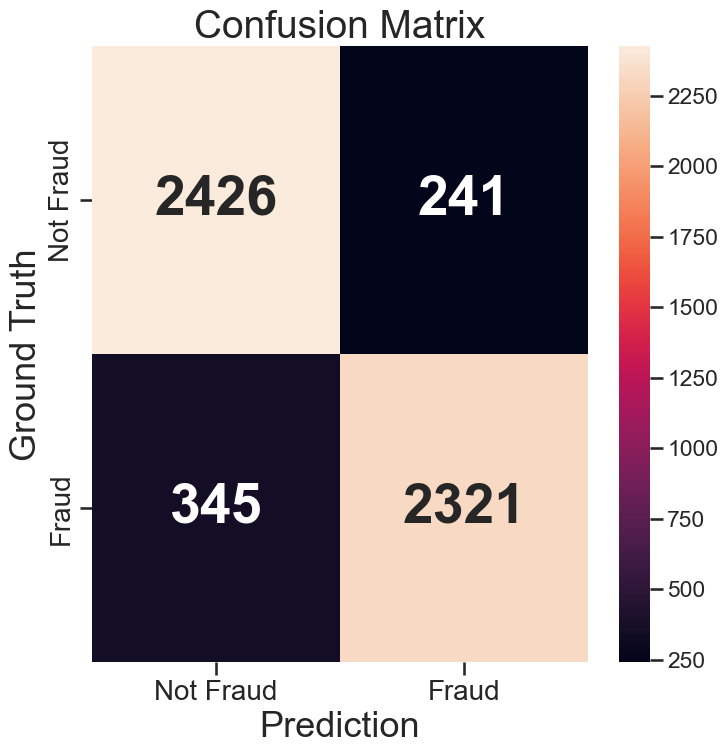

In [100]:
_, ax = plt.subplots(figsize=(8,8))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    annot_kws={"size": 40, "weight": "bold"},
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"],
    ax=ax
)

ax.set_xlabel("Prediction", fontsize=26)
ax.set_ylabel("Ground Truth", fontsize=26)
ax.tick_params(axis="both", labelsize=20)

plt.title("Confusion Matrix", fontsize=28)
plt.show()

In [101]:
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2426  241]
 [ 345 2321]]
              precision    recall  f1-score   support

           0       0.88      0.91      0.89      2667
           1       0.91      0.87      0.89      2666

    accuracy                           0.89      5333
   macro avg       0.89      0.89      0.89      5333
weighted avg       0.89      0.89      0.89      5333



88% of the time, the model correctly labels transactions as fradulent. However, it only catches 67% of all actual fraudulent cases.

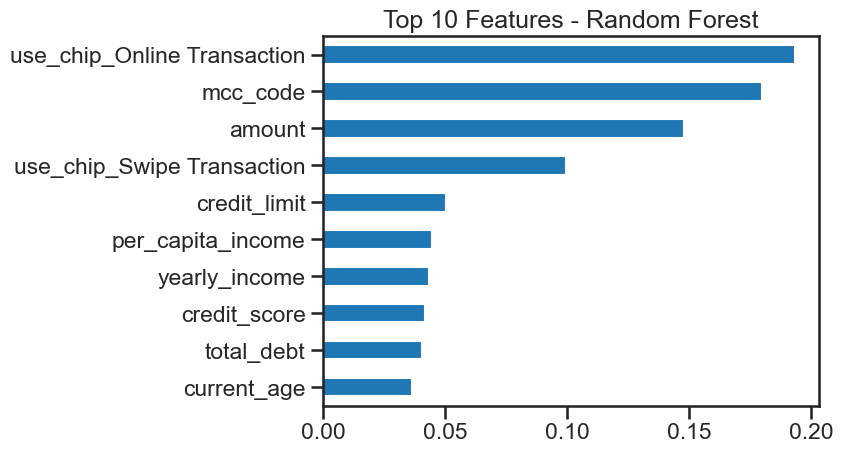

In [102]:
importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="barh")
plt.title("Top 10 Features - Random Forest")
plt.gca().invert_yaxis()
plt.show()

The top 3 important features in Random Forest Model are use_chip_Online Transaction, mcc_code, and amount.

### Extra Random Trees

This is still a random forest but it will choose features randomly at every split.

In [103]:
rf_extraRndm = ExtraTreesClassifier(
    n_estimators=300,
    max_features="log2",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_extraRndm.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=FalseWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",False
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [104]:
y_pred = rf_extraRndm.predict(X_test)

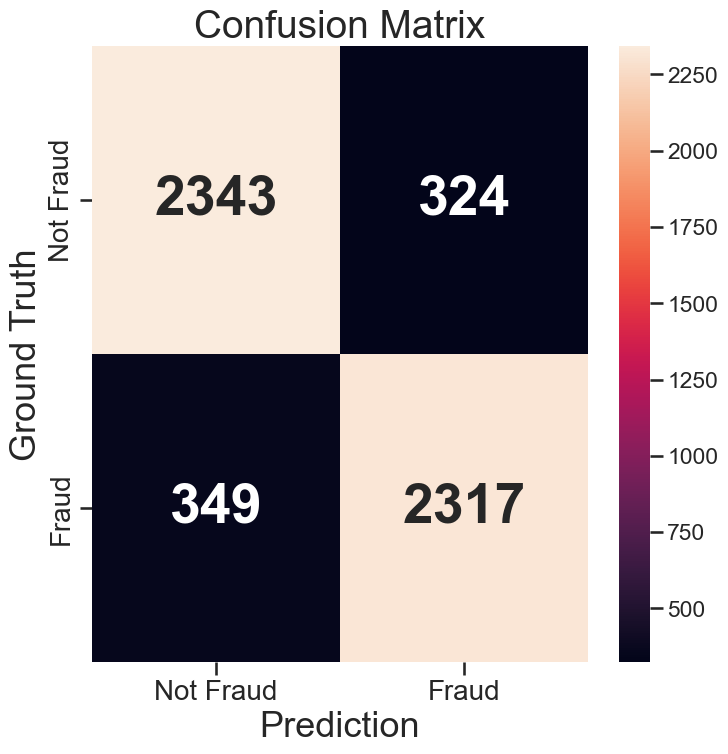

In [105]:
_, ax = plt.subplots(figsize=(8,8))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    annot_kws={"size": 40, "weight": "bold"},
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"],
    ax=ax
)

ax.set_xlabel("Prediction", fontsize=26)
ax.set_ylabel("Ground Truth", fontsize=26)
ax.tick_params(axis="both", labelsize=20)

plt.title("Confusion Matrix", fontsize=28)
plt.show()

In [106]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2343  324]
 [ 349 2317]]
              precision    recall  f1-score   support

           0       0.87      0.88      0.87      2667
           1       0.88      0.87      0.87      2666

    accuracy                           0.87      5333
   macro avg       0.87      0.87      0.87      5333
weighted avg       0.87      0.87      0.87      5333



Random forest model with extra random trees calls out fraud correctly 78 % of the time, same as regular random forest. However, it catches 68% of fraudulent cases, which is a slight improvement.

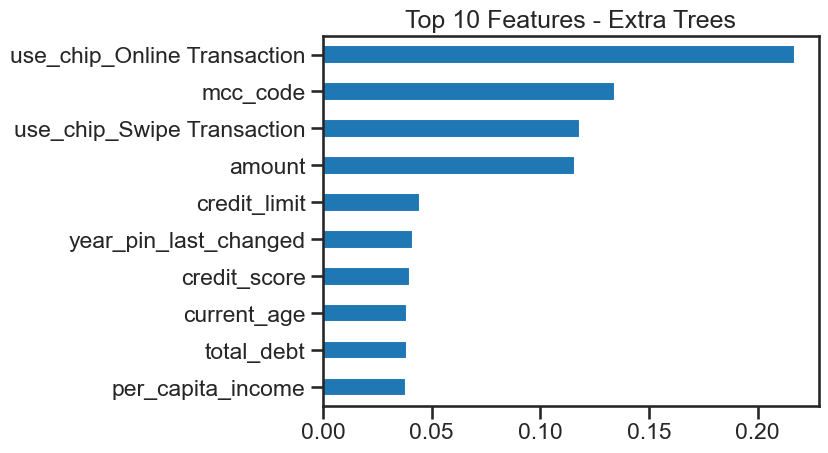

In [107]:
importance = pd.Series(
    rf_extraRndm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="barh")
plt.title("Top 10 Features - Extra Trees")
plt.gca().invert_yaxis()
plt.show()

The top 3 features are the same as Random Forest's.

### KNN

KNNs are distance based and will require scaling.

In [108]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [109]:
X_test_scaled

array([[ 0.21273618, -0.174023  ,  0.51906271, ..., -1.19897873,
        -0.30633534,  0.32712576],
       [ 0.00790907, -0.174023  , -0.12038648, ...,  0.83404315,
        -0.30633534,  0.32712576],
       [ 0.33065754, -0.174023  ,  0.77484239, ...,  0.83404315,
        -0.30633534,  0.32712576],
       ...,
       [-0.44622153, -0.174023  ,  0.26328303, ...,  0.83404315,
        -0.30633534,  0.32712576],
       [ 0.10393341, -0.174023  ,  1.35034666, ..., -1.19897873,
        -0.30633534,  0.32712576],
       [-0.42835653, -0.174023  ,  1.73401617, ...,  0.83404315,
        -0.30633534,  0.32712576]], shape=(5333, 19))

We will test KNNs with different K-values to determine the best number of closest neighbors.

In [110]:
max_k = 40
f1_scores = list()
error_rates = list() # 1-accuracy

for k in range(1, max_k):
    
    knn = KNeighborsClassifier(n_neighbors=k, weights='distance')
    knn = knn.fit(X_train_scaled, y_train)
    
    y_pred = knn.predict(X_test_scaled)
    f1 = f1_score(y_pred, y_test)
    f1_scores.append((k, round(f1_score(y_test, y_pred), 4)))
    error = 1-round(accuracy_score(y_test, y_pred), 4)
    error_rates.append((k, error))
    
f1_results = pd.DataFrame(f1_scores, columns=['K', 'F1 Score'])
error_results = pd.DataFrame(error_rates, columns=['K', 'Error Rate'])

Visualization of F1 score and error rate of different K values.

Text(0.5, 1.0, 'KNN F1 Score')

<Figure size 1920x1440 with 0 Axes>

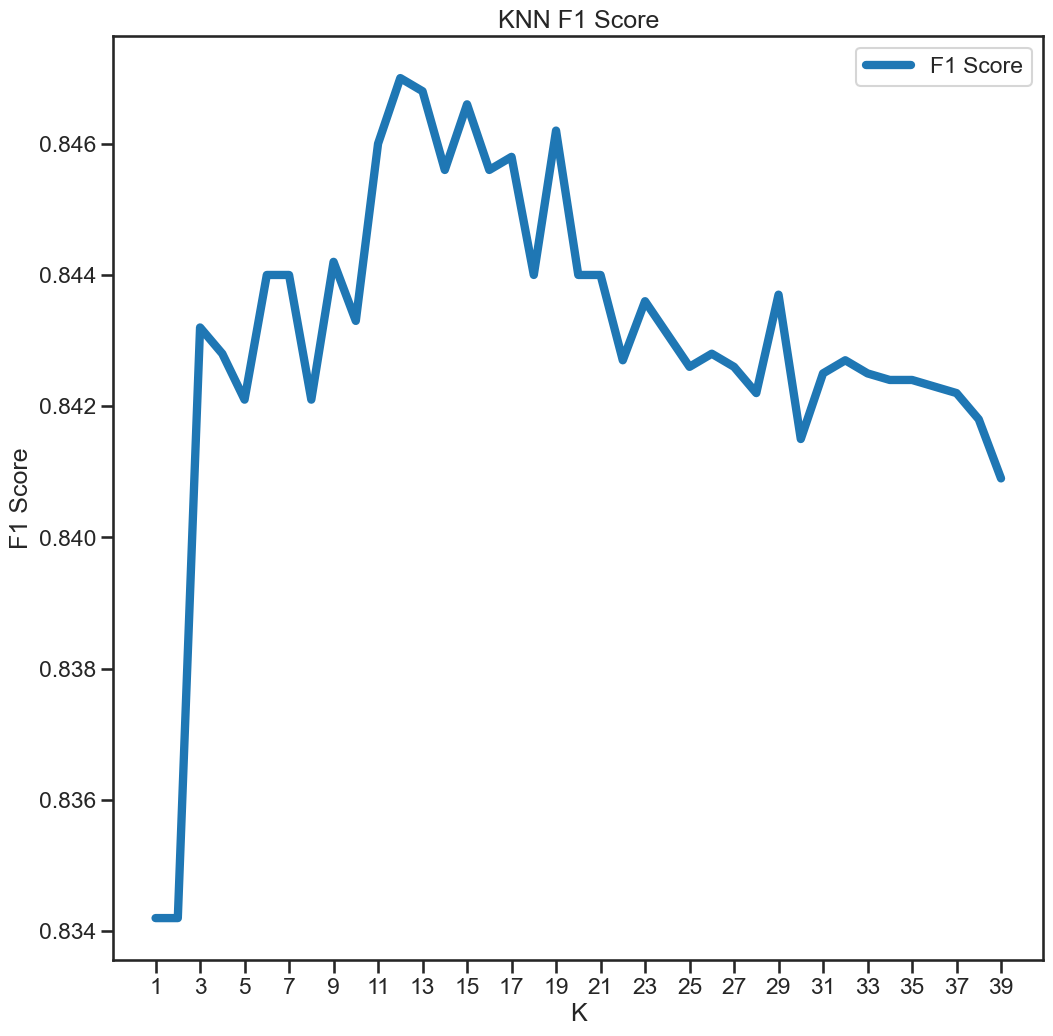

In [111]:
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)
ax = f1_results.set_index('K').plot(figsize=(12, 12), linewidth=6)
ax.set(xlabel='K', ylabel='F1 Score')
ax.set_xticks(range(1, max_k, 2));
plt.title('KNN F1 Score')

Text(0.5, 1.0, 'KNN Elbow Curve')

<Figure size 1920x1440 with 0 Axes>

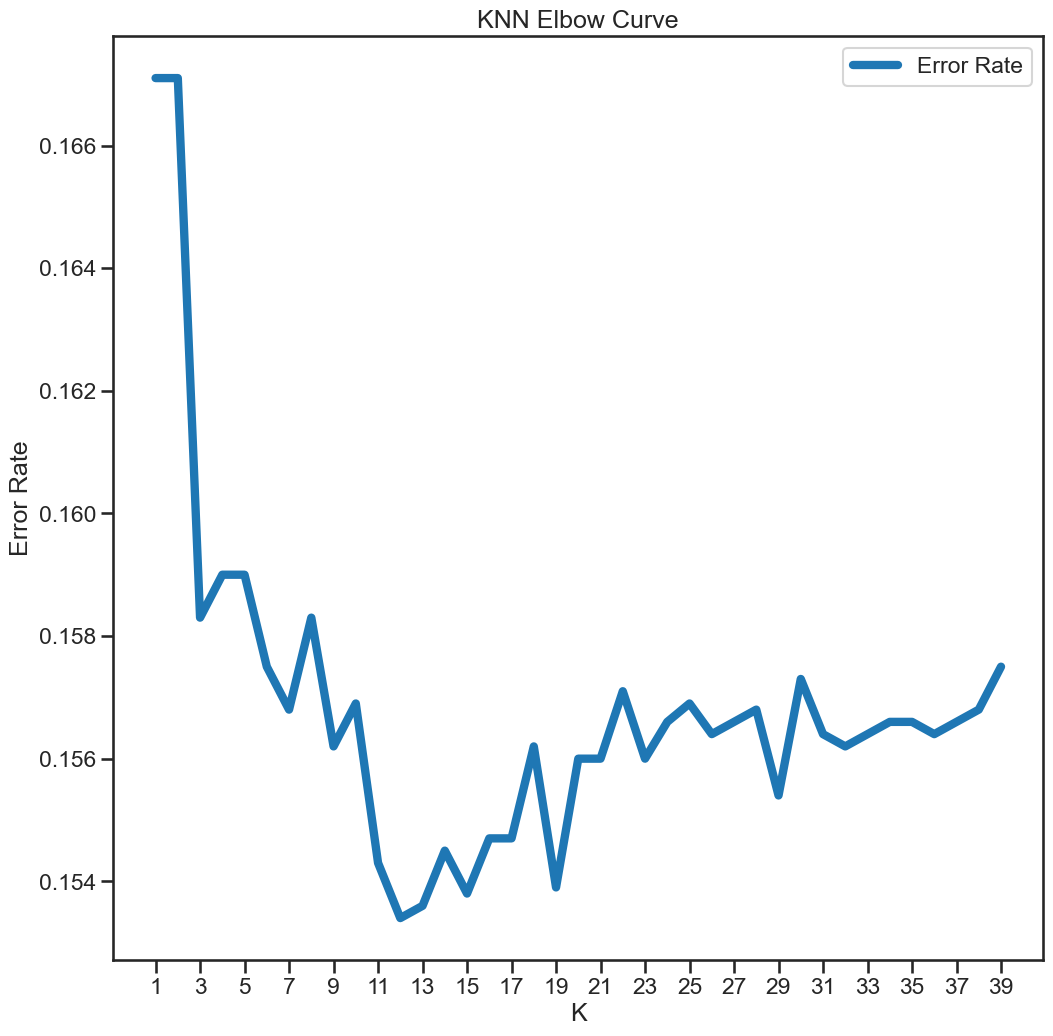

In [112]:
sns.set_context('talk')
sns.set_style('ticks')

plt.figure(dpi=300)
ax = error_results.set_index('K').plot(figsize=(12, 12), linewidth=6)
ax.set(xlabel='K', ylabel='Error Rate')
ax.set_xticks(range(1, max_k, 2))
plt.title('KNN Elbow Curve')

Since our model is imbalanced, we will look at F1 score graph to determine the k value. A low error rate can still be bad at detecting fraud. Below, we obtain the K value of the peak of the F1 Score graph.

In [113]:
optimal_k_value = f1_results.loc[f1_results["F1 Score"].idxmax(), "K"]
optimal_k_value

np.int64(12)

In [114]:
knn_model = KNeighborsClassifier(n_neighbors=optimal_k_value, weights="distance")

knn_model.fit(X_train_scaled, y_train.values.ravel())

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",np.int64(12)
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [115]:
knn_preds = knn_model.predict(X_test_scaled)

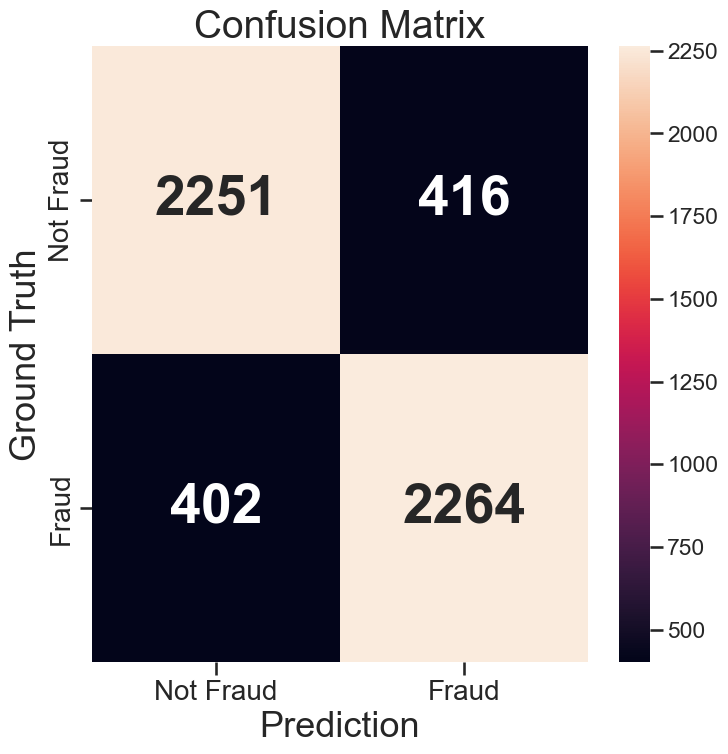

In [116]:
_, ax = plt.subplots(figsize=(8,8))

cm = confusion_matrix(y_test, knn_preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    annot_kws={"size": 40, "weight": "bold"},
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"],
    ax=ax
)

ax.set_xlabel("Prediction", fontsize=26)
ax.set_ylabel("Ground Truth", fontsize=26)
ax.tick_params(axis="both", labelsize=20)

plt.title("Confusion Matrix", fontsize=28)
plt.show()

In [117]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, knn_preds))
print(classification_report(y_test, knn_preds))

[[2251  416]
 [ 402 2264]]
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      2667
           1       0.84      0.85      0.85      2666

    accuracy                           0.85      5333
   macro avg       0.85      0.85      0.85      5333
weighted avg       0.85      0.85      0.85      5333



The KNN model correctly identifies fraud 73% of the time and catches 63% of fradulent cases.

### Boosting

This model sequentially corrects previous iterations.

In [118]:
boost_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42
)



In [119]:
boost_model.fit(X_train, y_train)

preds = boost_model.predict(X_test)



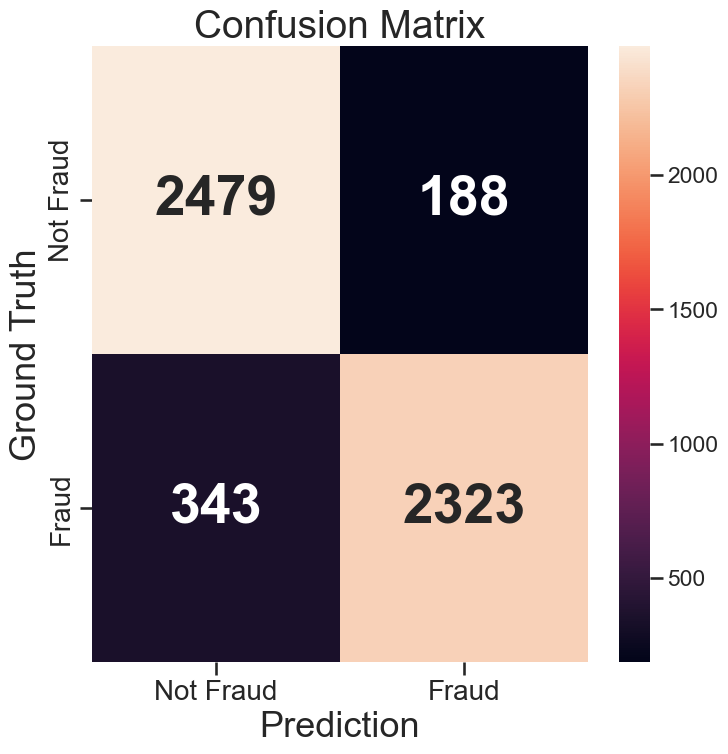

In [120]:
_, ax = plt.subplots(figsize=(8,8))

cm = confusion_matrix(y_test, preds)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    annot_kws={"size": 40, "weight": "bold"},
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"],
    ax=ax
)

ax.set_xlabel("Prediction", fontsize=26)
ax.set_ylabel("Ground Truth", fontsize=26)
ax.tick_params(axis="both", labelsize=20)

plt.title("Confusion Matrix", fontsize=28)
plt.show()

In [121]:
print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[2479  188]
 [ 343 2323]]
              precision    recall  f1-score   support

           0       0.88      0.93      0.90      2667
           1       0.93      0.87      0.90      2666

    accuracy                           0.90      5333
   macro avg       0.90      0.90      0.90      5333
weighted avg       0.90      0.90      0.90      5333



This model correctly identifies fraud 91% of the time and catches 70% of fraud cases.

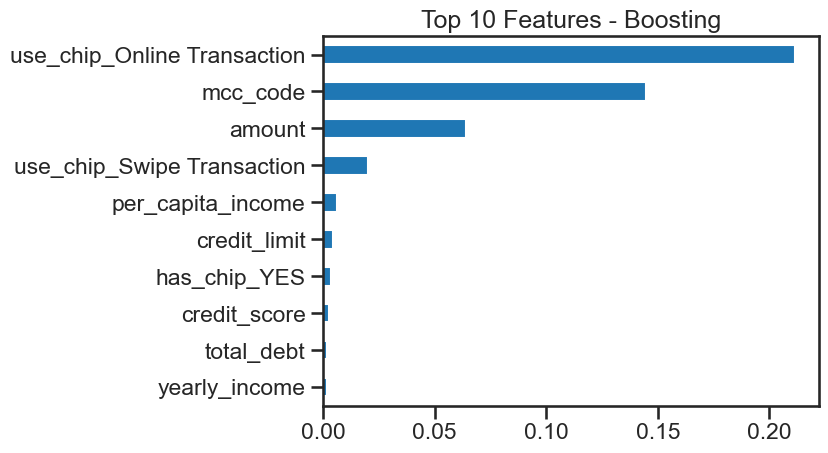

In [122]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    boost_model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="barh")
plt.title("Top 10 Features - Boosting")
plt.gca().invert_yaxis()
plt.show()

### Model Comparison

In [123]:
rf_preds = rf.predict(X_test)
extra_preds = rf_extraRndm.predict(X_test)
knn_preds = knn_model.predict(X_test_scaled)
boost_preds = boost_model.predict(X_test)

In [124]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

predictions = {
    "Random Forest": rf_preds,
    "Extra Trees": extra_preds,
    "KNN": knn_preds,
    "Boosting": boost_preds
}

results = []

for name, preds in predictions.items():
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Fraud Precision": precision_score(y_test, preds),
        "Fraud Recall": recall_score(y_test, preds),
        "Fraud F1": f1_score(y_test, preds),
        "False Positives": fp,
        "False Negatives": fn,
        "True Fraud Caught": tp
    })

comparison_df = pd.DataFrame(results).sort_values("Fraud F1", ascending=False)
comparison_df

,Model,Accuracy,Fraud Precision,Fraud Recall,Fraud F1,False Positives,False Negatives,True Fraud Caught
3,Boosting,0.900431,0.925129,0.871343,0.897431,188,343,2323
0,Random Forest,0.890118,0.905933,0.870593,0.887911,241,345,2321
1,Extra Trees,0.873805,0.877319,0.869092,0.873186,324,349,2317
2,KNN,0.846615,0.844776,0.849212,0.846988,416,402,2264


### Conclusion

In the model comparison, we can see that Boosting is the best performing model, with the highest F1 score. It correctly identifies fraud 91% of the time and catches almost 70% of all fraud cases. This excellent performance is due to the model's ability to reform previous iterations of its predictions. The next better performer is the Random Forest model. Extra Trees performed worse than Random Forest, most likely due to the randomness it introduces in terms of features and splits. Due to the nature of fraud data not being distance based, the KNN model performed the worst, with an F1 score of 0.67, compared to the F1 of 0.79 for Boosting. 

For Random Forest, Extra Trees, and Boosting, the top 3 important features are use_chip_Online Transaction (online transactions), mcc_code (merchant category code), and amount. 

### Limitations and Future Steps

This data may require a professional familiar with fradulent transaction data to select features. Some features may have been incorrectly deleted or kept. Consultation with an expert could help to improve feature selection.

Another model to try is stacking, where multiple models are trained and their preductions are combined by a final trained model.